### 河流图（ThemeRiver）

河流图（ThemeRiver）是一种用于可视化时间序列数据的图表类型，特别适合展示多个类别或变量随时间变化的趋势。河流图通过流动的“河流”形状表示数据的变化，每条“河流”代表一个类别，河流的宽度表示该类别在某个时间点的数值大小。河流图的特点是能够清晰地展示多个类别的相对变化趋势，同时保持整体的连贯性和美观性。

河流图的特点  
多类别展示：
河流图可以同时展示多个类别的时间序列数据，每个类别用不同的颜色表示。

时间维度：
河流图的横轴通常是时间，纵轴表示数值大小，河流的宽度反映数值的变化。

流动感：
河流图通过流动的形状展示数据的变化趋势，给人一种动态的感觉。

交互性：
河流图通常支持交互操作，如悬停显示数值、缩放时间范围等。

In [11]:
!pip install pyecharts

In [16]:
from pyecharts.charts import ThemeRiver
import pyecharts.options as opts
import pandas as pd

def load_data(file_path):
    """
    加载数据并转换为 ThemeRiver 所需的格式。

    参数:
    - file_path: 数据文件路径。

    返回:
    - data_list: 转换后的数据列表。
    - series: 系列名称列表。
    """
    # 导入数据
    data = pd.read_csv(file_path)
    
    # 封装数据
    data_list = []
    for i in zip(data['date'], data['num'], data['series']):
        data_list.append(list(i))
    
    # 获取系列名称
    series = data['series'].unique().tolist()
    
    return data_list, series

def create_theme_river(data_list, series, output_file='theme_river.html', height='600px'):
    """
    创建并渲染 ThemeRiver 图表。

    参数:
    - data_list: 数据列表。
    - series: 系列名称列表。
    - output_file: 输出文件名。
    - height: 图表高度。
    """
    # 绘制 ThemeRiver 图表
    theme_river = (
        ThemeRiver(init_opts=opts.InitOpts(height=height))
        .add(
            series_name=series,
            data=data_list,
            singleaxis_opts=opts.SingleAxisOpts(type_='time')
        )
        .render(output_file)
    )
    print(f"图表已保存为 {output_file}")
    print(f"请在文件夹中用浏览器打开{output_file}查看")

# 主程序
if __name__ == '__main__':
    # 加载数据
    data_list, series = load_data('river_data.csv')
    
    # 创建并渲染 ThemeRiver 图表
    create_theme_river(data_list, series)

图表已保存为 theme_river.html
请在文件夹中用浏览器打开theme_river.html查看


## 使用matplotlib绘制河流图

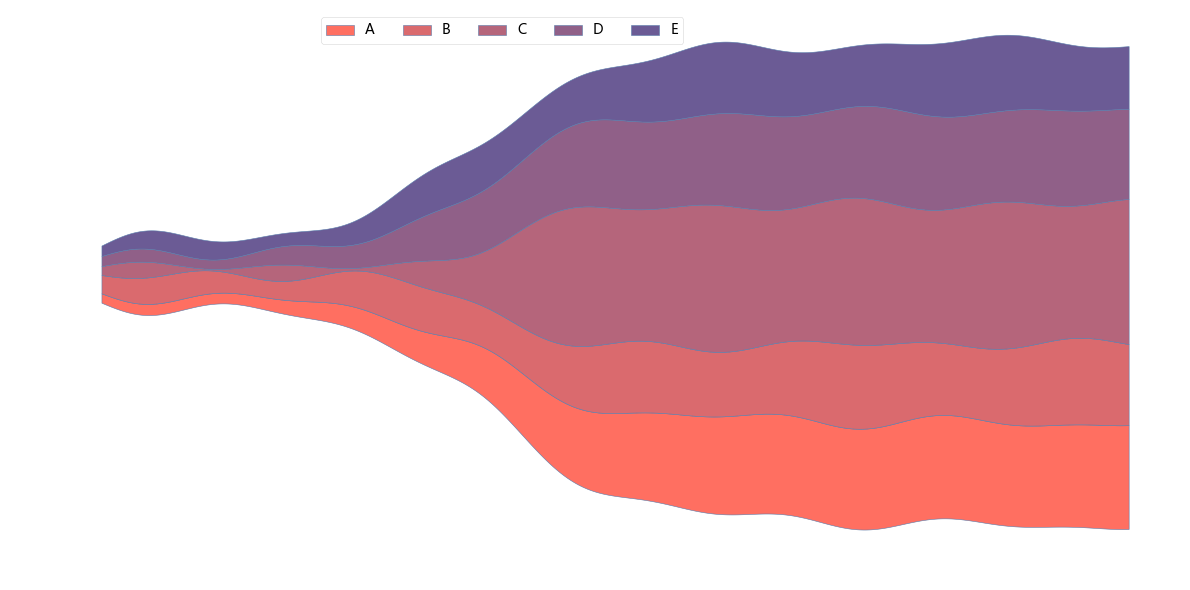

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# 设置全局样式
def configure_global_styles():
    plt.rcParams.update({
        "font.sans-serif": ["Microsoft YaHei"],  # 支持中文显示
        "axes.unicode_minus": False,            # 显示负号
        "axes.edgecolor": "#ffffff",            # 隐藏边框
        "axes.labelweight": "bold",             # 轴标签加粗
        "xtick.color": "#ffffff",               # x轴刻度颜色
        "ytick.color": "#ffffff",               # y轴刻度颜色
        "patch.force_edgecolor": True,          # 启用分界线
        "patch.edgecolor": "#597cab",           # 分界线颜色
        "patch.linewidth": 0.4                  # 分界线宽度
    })

# 生成平滑过渡函数
def smooth_transition(t, start_val, end_val, transition_start, transition_end):
    """生成平滑过渡的 S 形曲线"""
    return start_val + (end_val - start_val) / (1 + np.exp(-(t - transition_start) / (transition_end - transition_start)))

# 生成随机正弦波
def generate_random_sine(time, amplitude, frequency):
    """生成带有随机振幅和频率的正弦波"""
    return amplitude * np.sin(frequency * time) + amplitude

# 创建示例数据集
def generate_sample_data():
    time = np.linspace(0, 100, 500)  # 时间序列
    datasets = []
    for _ in range(5):
        base_data = smooth_transition(
            time,
            np.random.uniform(0, 5),
            np.random.uniform(10, 50),
            np.random.uniform(30, 40),
            np.random.uniform(40, 50),
        )
        base_data += generate_random_sine(time, np.random.uniform(0, 3), np.random.uniform(0.1, 0.5))
        datasets.append(base_data)
    return time, datasets

# 生成渐变色列表
def generate_gradient_colors(start_hex, end_hex, num_colors):
    """生成从起始颜色到结束颜色的渐变色列表"""
    start_rgb = mcolors.hex2color(start_hex)
    end_rgb = mcolors.hex2color(end_hex)
    return [mcolors.to_hex((
        start_rgb[0] * (1 - ratio) + end_rgb[0] * ratio,
        start_rgb[1] * (1 - ratio) + end_rgb[1] * ratio,
        start_rgb[2] * (1 - ratio) + end_rgb[2] * ratio,
    )) for ratio in np.linspace(0, 1, num_colors)]

# 主程序
if __name__ == "__main__":
    # 设置全局样式
    configure_global_styles()

    # 生成示例数据
    time, datasets = generate_sample_data()

    # 定义渐变色
    gradient_colors = generate_gradient_colors("#FF6F61", "#6B5B95", len(datasets))  # 从珊瑚红到紫水晶

    # 绘制堆积面积图
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        time,
        np.vstack(datasets),
        baseline="wiggle",
        labels=["A", "B", "C", "D", "E"],
        colors=gradient_colors,
    )
    ax.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.4, 1.0))
    plt.tight_layout()
    plt.savefig('主题河流图1.png', dpi=300)
    plt.show()